# Audit of a published claim — donor-specific coordination under cytokine stimulation (Zahid 2026)

**Claim (Zahid, bioRxiv 2026, Fig. 8B):** on the Parse 10M PBMC data, responses to each cytokine are coordinated across cell types *within donors*: for every one of the 90 cytokines, within-donor coordination (median Spearman between the cell types' response vectors; observed median 0.68) exceeds a donor-permuted null (median 0.36). Responses were defined against the donor-matched **PBS** profile.

**Why it may be technical:** each donor has its own plate, and all PBS wells sit in the edge row. We showed that PBS carries a non-specific shift relative to every other well. This shift differs between plates (donors) and is subtracted from every cell type of the same donor, so it can produce donor-specific coordination across cell types without any biology.

**Tests:**
1. Reproduce the analysis with the **PBS reference** (as published).
2. **Negative controls:** 13 cytokines that are biologically inert on PBMCs. If they show donor-specific coordination as strong as immune cytokines, the coordination is technical.
3. Repeat with the **inert-cytokine reference** (each inert cytokine is referenced to the mean of the *other* inert cytokines).
4. **Pure-technical control:** a pseudo-response built from the PBS wells alone (mean of wells H7-H9 minus mean of H10-H12, per donor and cell type). Any donor-specific coordination here is technical by construction.

**Approximations to the published pipeline:** pseudobulk log-normalized profiles (the paper reports that pseudobulk aggregation gives consistent results) instead of means of per-cell values; Spearman correlation in gene space (a shared gene set of well-expressed genes) instead of the 150-component ITL space learned on an external cohort, which is not available here. Groups need at least 100 cells, as in the paper.

Uses the cached pseudobulks of `aim1_compass_parse.ipynb` (sections 2 and 6c).

In [1]:
import os
import numpy as np, pandas as pd
from scipy.stats import rankdata
import matplotlib.pyplot as plt, seaborn as sns

CACHE_DIR = "data/parse10m/cache"
RESULTS_DIR = "results/aim1_zahid_audit"
os.makedirs(RESULTS_DIR, exist_ok=True)

CONTROL = "PBS"
INERT = ["Noggin", "Decorin", "PSPN", "GDNF", "Megalin", "PRL", "EPO", "TPO", "FGF-beta", "EGF", "HGF", "VEGF", "IGF-1"]
#INERT = ["TPO", "Megalin", "PSPN", "EPO", "EGF"]
MIN_CELLS = 100          # as in the paper
MIN_DONORS_CT = 10       # a cell type is used if at least this many donors have >= MIN_CELLS PBS cells
N_GENES = 3500           # size of the shared gene set (paper: 3,438)
N_PERM = 500
TARGET = 1e4
SEED = 0

sums = np.load(os.path.join(CACHE_DIR, "pb_sums.npy"))
meta = pd.read_pickle(os.path.join(CACHE_DIR, "pb_meta.pkl")).reset_index(drop=True)
genes = np.load(os.path.join(CACHE_DIR, "pb_genes.npy"), allow_pickle=True).astype(str)
print("pseudobulk groups:", sums.shape, "| cytokines:", meta.cytokine.nunique(), "| donors:", meta.donor.nunique())

pseudobulk groups: (26162, 40352) | cytokines: 91 | donors: 12


## 1. Full profiles (both halves), cell types and shared gene set

In [2]:
# sum the two halves: one profile per donor x cell type x cytokine
key = meta[["donor", "cell_type", "cytokine"]].astype(str).agg("|".join, axis=1)
codes, uniq = pd.factorize(key)
FULL = np.zeros((len(uniq), sums.shape[1]), np.float64)
np.add.at(FULL, codes, sums)
FMETA = pd.DataFrame([u.split("|") for u in uniq], columns=["donor", "cell_type", "cytokine"])
FMETA["n_cells"] = np.bincount(codes, weights=meta.n_cells.to_numpy(), minlength=len(uniq)).astype(int)
FMETA = FMETA[FMETA.n_cells >= MIN_CELLS].copy()
LOOK = {(r.donor, r.cell_type, r.cytokine): i for i, r in FMETA.iterrows()}

pbs_ok = FMETA[FMETA.cytokine == CONTROL].groupby("cell_type").donor.nunique()
CELL_TYPES = sorted(pbs_ok[pbs_ok >= MIN_DONORS_CT].index)
DONORS = sorted(FMETA.donor.unique())
print("cell types used:", CELL_TYPES)

def lognorm(x): return np.log1p(x / max(x.sum(), 1) * TARGET)

# shared gene set: well expressed in PBS of every used cell type (no mitochondrial / ribosomal genes)
ok_gene = ~pd.Series(genes).str.upper().str.match(r"^(MT-|RPL|RPS)").to_numpy()
mean_expr = np.array([np.mean([lognorm(FULL[LOOK[(d, ct, CONTROL)]]) for d in DONORS if (d, ct, CONTROL) in LOOK], 0)
                      for ct in CELL_TYPES])
score = np.where(ok_gene, mean_expr.min(0), -np.inf)          # expressed in all cell types
GIDX = np.argsort(score)[::-1][:N_GENES]
print(f"shared gene set: {len(GIDX)} genes")

def profile(d, ct, c):
    i = LOOK.get((d, ct, c))
    return None if i is None else lognorm(FULL[i])[GIDX]

cell types used: ['B', 'CD14 Mono', 'CD16 Mono', 'CD4 T', 'CD8 T', 'MAIT', 'NK', 'NK CD56bright', 'NKT', 'Treg', 'cDC']
shared gene set: 3500 genes


## 2. Responses under each reference

In [3]:
CYTOS = sorted(c for c in FMETA.cytokine.unique() if c != CONTROL)
inert_present = [c for c in INERT if c in CYTOS]

def responses(ref):
    # returns {cytokine: {cell_type: {donor: response vector}}}
    out = {}
    for c in CYTOS:
        out[c] = {}
        for ct in CELL_TYPES:
            out[c][ct] = {}
            for d in DONORS:
                x = profile(d, ct, c)
                if x is None: continue
                if ref == "PBS":
                    r0 = profile(d, ct, CONTROL)
                else:   # inert reference; an inert cytokine is referenced to the other inert cytokines
                    refs = [profile(d, ct, k) for k in inert_present if k != c]
                    refs = [v for v in refs if v is not None]
                    r0 = np.mean(refs, 0) if len(refs) >= 3 else None
                if r0 is not None: out[c][ct][d] = x - r0
    return out

RESP = {"PBS": responses("PBS"), "inert": responses("inert")}
print("done")

done


## 3. Within-donor coordination and donor-permuted null
Coordination of a cytokine = median over donors of the median Spearman correlation between the donor's cell-type response vectors (all cell-type pairs). Null: donor labels permuted independently within each cell type, which keeps the part of coordination that comes from a shared response to the cytokine but breaks donor matching.

In [4]:
rng = np.random.default_rng(SEED)
def zrank(v):
    r = rankdata(v); r = r - r.mean(); return r / np.linalg.norm(r)

def coordination(resp_c, n_perm=N_PERM):
    # As in the paper: for each donor, median Spearman over the cell-type pairs available for that donor,
    # then the median over donors. Cell types need >= 3 donors; donors need >= 2 cell types.
    cts = [ct for ct in CELL_TYPES if len(resp_c.get(ct, {})) >= 3]
    if len(cts) < 2: return None
    dl = {ct: sorted(resp_c[ct]) for ct in cts}                          # donors present per cell type
    pos = {ct: {d: i for i, d in enumerate(dl[ct])} for ct in cts}
    Z = {ct: np.array([zrank(resp_c[ct][d]) for d in dl[ct]]) for ct in cts}
    pairs = [(a, b) for i, a in enumerate(cts) for b in cts[i + 1:]]
    Cm = {(a, b): Z[a] @ Z[b].T for a, b in pairs}                      # donor x donor Spearman
    donors = sorted({d for ct in cts for d in dl[ct]})
    slots = {d: [(a, b) for a, b in pairs if d in pos[a] and d in pos[b]] for d in donors}
    donors = [d for d in donors if slots[d]]
    if len(donors) < 4: return None
    def stat(perm):
        per_donor = [np.median([Cm[(a, b)][perm[a][pos[a][d]], perm[b][pos[b][d]]] for a, b in slots[d]])
                     for d in donors]
        return np.median(per_donor)
    obs = stat({ct: np.arange(len(dl[ct])) for ct in cts})
    null = np.array([stat({ct: rng.permutation(len(dl[ct])) for ct in cts}) for _ in range(n_perm)])
    return dict(n_donors=len(donors), n_cell_types=len(cts), observed=obs, null_median=np.median(null),
                p=(1 + np.sum(null >= obs)) / (1 + n_perm))

rows = []
for ref, R in RESP.items():
    for c in CYTOS:
        r = coordination(R[c])
        if r: rows.append(dict(reference=ref, cytokine=c, inert=c in INERT, **r))
COORD = pd.DataFrame(rows)
COORD["excess"] = COORD.observed - COORD.null_median
COORD.to_csv(f"{RESULTS_DIR}/coordination_per_cytokine.csv", index=False)

SUMMARY = (COORD.groupby(["reference", "inert"])
           .agg(n_cytokines=("cytokine", "count"), observed=("observed", "median"), null=("null_median", "median"),
                excess=("excess", "median"), frac_p_below_005=("p", lambda p: (p < 0.05).mean()))
           .round(3))
SUMMARY.to_csv(f"{RESULTS_DIR}/coordination_summary.csv")
SUMMARY

n_cytokines  observed   null  excess  frac_p_below_005
reference inert                                                        
PBS       False           77     0.334  0.198   0.118               1.0
          True            13     0.293  0.201   0.095               1.0
inert     False           77     0.297  0.188   0.105               1.0
          True            13     0.272  0.193   0.078               1.0

## 4. Pure-technical control from the PBS wells
Pseudo-response = mean profile of PBS wells H7-H9 minus mean of H10-H12, per donor and cell type (no stimulus at all). Uses the PBS-well cache from section 6c of the main notebook.

In [5]:
wsums = np.load(os.path.join(CACHE_DIR, "pbs_wells.npz"))["sums"]
wmeta = pd.read_pickle(os.path.join(CACHE_DIR, "pbs_wells_meta.pkl")).reset_index(drop=True)
GROUP1, GROUP2 = ["H7", "H8", "H9"], ["H10", "H11", "H12"]
pseudo = {}
for ct in CELL_TYPES:
    pseudo[ct] = {}
    for d in DONORS:
        parts = []
        for grp in (GROUP1, GROUP2):
            m = (wmeta.donor == d) & (wmeta.cell_type == ct) & wmeta.well.isin(grp)
            if wmeta[m].n_cells.sum() < MIN_CELLS / 2: break
            parts.append(lognorm(wsums[wmeta[m].index.to_numpy()].sum(0))[GIDX])
        if len(parts) == 2: pseudo[ct][d] = parts[0] - parts[1]
TECH = coordination(pseudo)
print("PBS-well pseudo-response (technical only):", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in TECH.items()} if TECH else "not enough cells")
pd.DataFrame([TECH]).to_csv(f"{RESULTS_DIR}/pbs_well_pseudo_response.csv", index=False)

PBS-well pseudo-response (technical only): {'n_donors': 12, 'n_cell_types': 6, 'observed': np.float64(0.506), 'null_median': np.float64(0.402), 'p': np.float64(0.002)}


## 5. Figure (as in the paper's Fig. 8B, for both references)

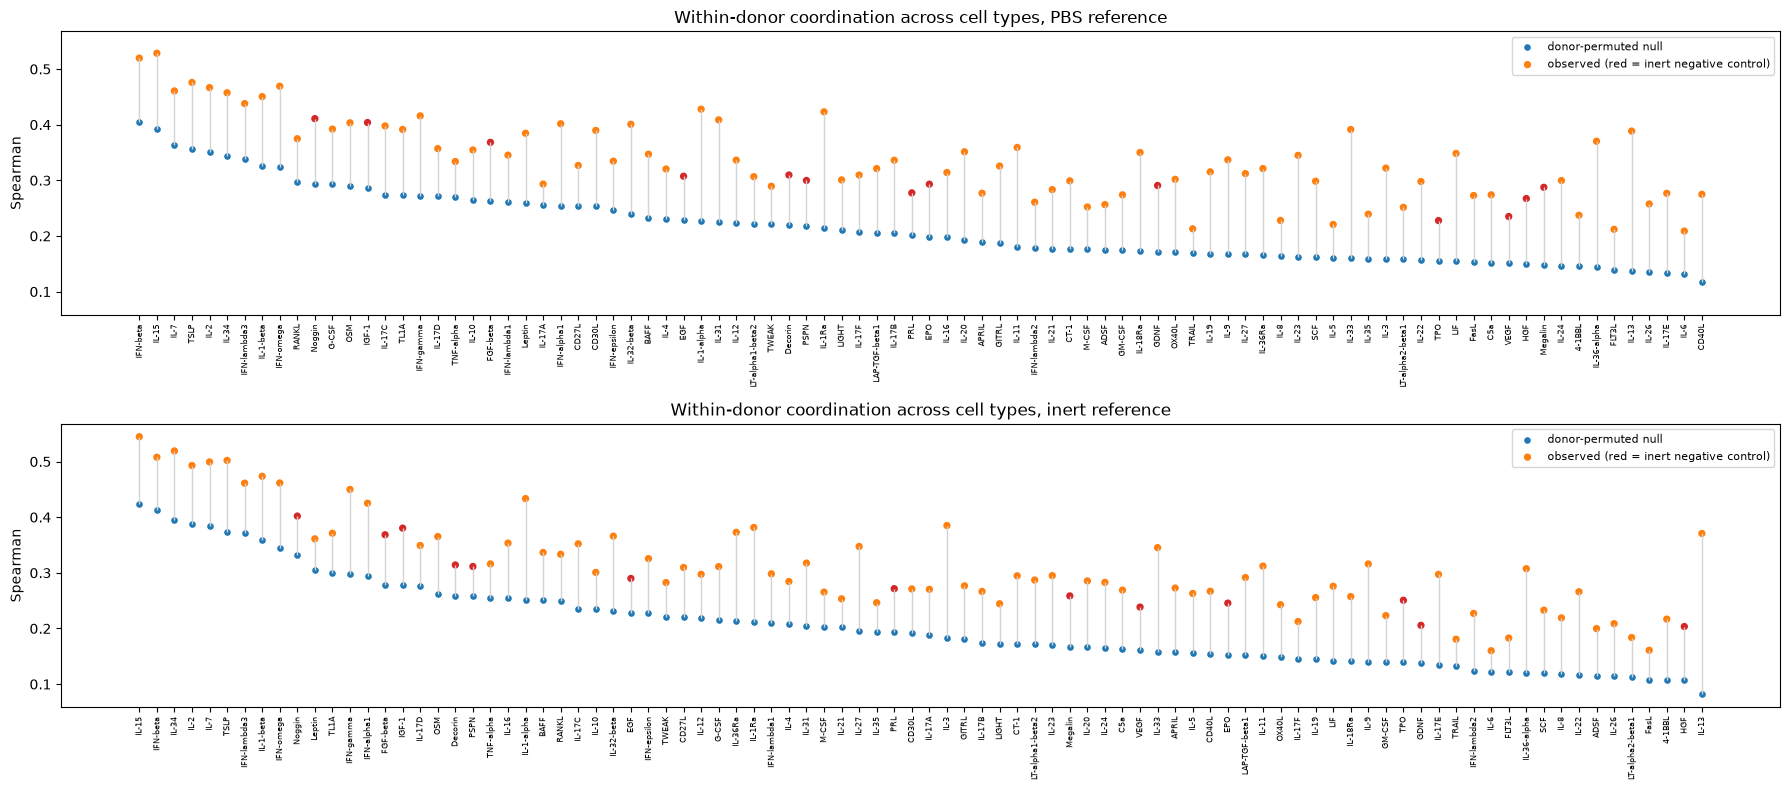

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(18, 8), sharey=True)
for a, ref in zip(ax, ["PBS", "inert"]):
    d = COORD[COORD.reference == ref].sort_values("null_median", ascending=False).reset_index(drop=True)
    a.vlines(d.index, d.null_median, d.observed, color="lightgrey", lw=1)
    a.scatter(d.index, d.null_median, s=14, color="tab:blue", label="donor-permuted null")
    a.scatter(d.index, d.observed, s=18, color=np.where(d.inert, "tab:red", "tab:orange"),
              label="observed (red = inert negative control)")
    a.set_xticks(d.index); a.set_xticklabels(d.cytokine, rotation=90, fontsize=6)
    a.set_title(f"Within-donor coordination across cell types, {ref} reference"); a.set_ylabel("Spearman")
    a.legend(fontsize=8, loc="upper right")
plt.tight_layout(); fig.savefig(f"{RESULTS_DIR}/coordination_by_reference.png", dpi=150, bbox_inches="tight"); plt.show()

## 6. Is coordination above the technical level?
The donor-permuted null of the paper pairs different wells, so it removes any effect shared by all cell types of the same well. Every donor x cytokine is a single well, so such well-level effects look donor-specific. The appropriate comparison is therefore against coordination that is **technical by construction**: the inert cytokines and the PBS-well pseudo-response.

- `immune_above_inert95`: share of immune cytokines whose excess exceeds the 95th percentile of the inert cytokines' excess
- Mann-Whitney test of immune vs inert excess

In [7]:
from scipy.stats import mannwhitneyu
rows = []
for ref, g in COORD.groupby("reference"):
    imm, ine = g[~g.inert].excess, g[g.inert].excess
    thr = np.quantile(ine, 0.95)
    rows.append(dict(reference=ref, immune_excess_median=imm.median(), inert_excess_median=ine.median(),
                     technical_share=ine.median() / imm.median(),
                     immune_above_inert95=(imm > thr).mean(),
                     p_mannwhitney=mannwhitneyu(imm, ine, alternative="greater").pvalue,
                     pbs_well_pseudo_excess=TECH["observed"] - TECH["null_median"] if TECH else np.nan))
ABOVE_TECH = pd.DataFrame(rows).set_index("reference").round(3)
ABOVE_TECH.to_csv(f"{RESULTS_DIR}/coordination_above_technical.csv")
ABOVE_TECH_LIST = COORD.assign(above_inert95=lambda d: d.excess > d.groupby("reference").apply(
    lambda g: np.quantile(g[g.inert].excess, 0.95)).reindex(d.reference).to_numpy())
ABOVE_TECH_LIST[~ABOVE_TECH_LIST.inert & ABOVE_TECH_LIST.above_inert95].sort_values(["reference", "excess"], ascending=[True, False]) \
    .to_csv(f"{RESULTS_DIR}/immune_cytokines_above_technical.csv", index=False)
display(ABOVE_TECH)
print("Immune cytokines above the inert 95th percentile (inert reference):",
      ABOVE_TECH_LIST[(ABOVE_TECH_LIST.reference == "inert") & ~ABOVE_TECH_LIST.inert & ABOVE_TECH_LIST.above_inert95]
      .sort_values("excess", ascending=False).cytokine.tolist())

,immune_excess_median,inert_excess_median,technical_share,immune_above_inert95,p_mannwhitney,pbs_well_pseudo_excess
reference,,,,,,
PBS,0.118,0.095,0.801,0.390,0.028,0.105
inert,0.105,0.078,0.745,0.494,0.004,0.105


Immune cytokines above the inert 95th percentile (inert reference): ['IL-13', 'IL-3', 'IL-33', 'IL-36-alpha', 'IL-1-alpha', 'IL-9', 'IL-1Ra', 'IL-17E', 'IL-11', 'IL-36Ra', 'IFN-gamma', 'IL-27', 'IL-22', 'LAP-TGF-beta1', 'IL-32-beta', 'LIF', 'IFN-alpha1', 'TSLP', 'IL-34', 'IL-23', 'CT-1', 'IL-15', 'IL-20', 'IL-24', 'IL-17C', 'IFN-omega', 'IL-18Ra', 'IL-7', 'APRIL', 'LT-alpha1-beta2', 'IL-1-beta', 'IL-31', 'SCF', 'CD40L', 'IL-19', '4-1BBL', 'IL-5', 'C5a']


## 7. Does the excess track how strongly a cytokine acts on PBMCs?
If coordination above the technical level were biological, it should be larger for cytokines that change PBMC transcription strongly. Response strength = median over donors and cell types of the norm of the inert-referenced response. Spearman between strength and excess, over immune cytokines.

Immune cytokines: Spearman(response strength, coordination excess) = 0.246 (p = 0.0311, n = 77)
Strongest responders:   cytokine  strength  excess
  IFN-beta    12.985   0.095
 IFN-omega    11.575   0.116
     IL-15    11.238   0.121
      IL-2     9.935   0.105
      IL-7     8.683   0.115
 IL-1-beta     8.310   0.115
      IL-4     8.043   0.077
IL-32-beta     7.984   0.135
 IFN-gamma     7.825   0.152
     IL-10     7.781   0.066


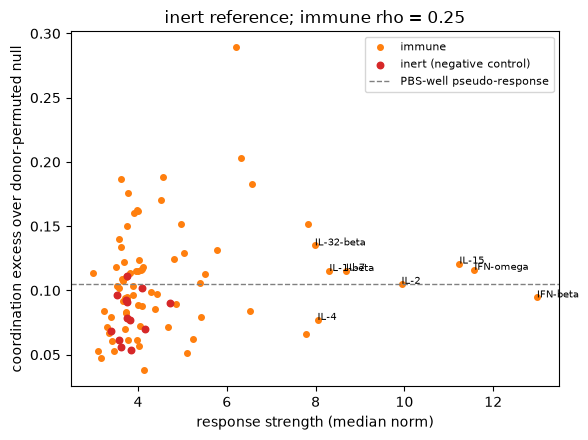

In [8]:
from scipy.stats import spearmanr
strength = {}
for c in CYTOS:
    norms = [np.linalg.norm(v) for ct in CELL_TYPES for v in RESP["inert"][c].get(ct, {}).values()]
    if norms: strength[c] = np.median(norms)
S = COORD[(COORD.reference == "inert")].assign(strength=lambda d: d.cytokine.map(strength)).dropna(subset=["strength"])
imm = S[~S.inert]
rho, p = spearmanr(imm.strength, imm.excess)
print(f"Immune cytokines: Spearman(response strength, coordination excess) = {rho:.3f} (p = {p:.3g}, n = {len(imm)})")
print("Strongest responders:", imm.sort_values("strength", ascending=False).head(10)[["cytokine", "strength", "excess"]].round(3).to_string(index=False))
S.to_csv(f"{RESULTS_DIR}/coordination_vs_strength.csv", index=False)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(S[~S.inert].strength, S[~S.inert].excess, s=16, color="tab:orange", label="immune")
ax.scatter(S[S.inert].strength, S[S.inert].excess, s=22, color="tab:red", label="inert (negative control)")
if TECH: ax.axhline(TECH["observed"] - TECH["null_median"], color="grey", ls="--", lw=1, label="PBS-well pseudo-response")
for _, r in S[~S.inert].nlargest(8, "strength").iterrows(): ax.annotate(r.cytokine, (r.strength, r.excess), fontsize=7)
ax.set_xlabel("response strength (median norm)"); ax.set_ylabel("coordination excess over donor-permuted null")
ax.set_title(f"inert reference; immune rho = {rho:.2f}"); ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig(f"{RESULTS_DIR}/coordination_vs_strength.png", dpi=150); plt.show()

## 8. Does the result depend on the comparison space?
The paper measured coordination in a 150-component space (ITL) learned on an external cohort, which is not available. Our argument is structural: an effect shared by all cell types of the same well survives any linear projection. The analysis is therefore repeated in several spaces:
- **gene space** (sections 3-7)
- **Parse baseline PCA**: PCA of donor deviation profiles of PBS cells (each cell type centered across donors), the closest analog of the ITL construction available within Parse (limited to the number of donor x cell-type profiles)
- **Parse response PCA (150)**: PCA of all PBS-referenced responses
- **random (150)**: a random orthonormal 150-dimensional subspace

If inert cytokines and the stimulus-free PBS-well pseudo-response show coordination comparable to immune cytokines in every space, the conclusion does not depend on the space.

In [9]:
rng_s = np.random.default_rng(1)
N_COMP = 150

# baseline deviation profiles: PBS profile of each donor x cell type, centered per cell type
dev = []
for ct in CELL_TYPES:
    P = np.array([profile(d, ct, CONTROL) for d in DONORS if profile(d, ct, CONTROL) is not None])
    dev.append(P - P.mean(0))
dev = np.vstack(dev)
_, _, Vt_base = np.linalg.svd(dev, full_matrices=False)

allresp = np.array([v for c in CYTOS for ct in CELL_TYPES for v in RESP["PBS"][c].get(ct, {}).values()])
allresp = allresp - allresp.mean(0)
_, _, Vt_resp = np.linalg.svd(allresp, full_matrices=False)

Q, _ = np.linalg.qr(rng_s.normal(size=(len(GIDX), N_COMP)))
SPACES = {"gene space": None,
          f"Parse baseline PCA ({min(N_COMP, Vt_base.shape[0])})": Vt_base[:N_COMP],
          f"Parse response PCA ({N_COMP})": Vt_resp[:N_COMP],
          f"random ({N_COMP})": Q.T}

def project(resp_c, B):
    return resp_c if B is None else {ct: {d: B @ v for d, v in dd.items()} for ct, dd in resp_c.items()}

rows, tech_rows = [], []
for space, B in SPACES.items():
    for ref, R in RESP.items():
        for c in CYTOS:
            r = coordination(project(R[c], B), n_perm=200)
            if r: rows.append(dict(space=space, reference=ref, cytokine=c, inert=c in INERT, **r))
    t = coordination(project(pseudo, B), n_perm=500)
    if t: tech_rows.append(dict(space=space, pbs_well_excess=t["observed"] - t["null_median"], pbs_well_p=t["p"]))
    print("done:", space)
SPACE_COORD = pd.DataFrame(rows)
SPACE_COORD["excess"] = SPACE_COORD.observed - SPACE_COORD.null_median
SPACE_COORD.to_csv(f"{RESULTS_DIR}/coordination_by_space.csv", index=False)

SPACE_SUMMARY = (SPACE_COORD.groupby(["space", "reference"])
    .apply(lambda g: pd.Series({
        "immune_observed": g[~g.inert].observed.median(), "immune_null": g[~g.inert].null_median.median(),
        "immune_excess": g[~g.inert].excess.median(), "inert_excess": g[g.inert].excess.median(),
        "technical_share": g[g.inert].excess.median() / g[~g.inert].excess.median(),
        "inert_significant": (g[g.inert].p < 0.05).mean()}))
    .join(pd.DataFrame(tech_rows).set_index("space"), on="space").round(3))
SPACE_SUMMARY.to_csv(f"{RESULTS_DIR}/coordination_by_space_summary.csv")
SPACE_SUMMARY

done: gene space
done: Parse baseline PCA (129)
done: Parse response PCA (150)
done: random (150)


immune_observed  immune_null  \
space                    reference                                 
Parse baseline PCA (129) PBS                  0.344        0.192   
                         inert                0.388        0.230   
Parse response PCA (150) PBS                  0.431        0.315   
                         inert                0.518        0.397   
gene space               PBS                  0.334        0.198   
                         inert                0.297        0.188   
random (150)             PBS                  0.420        0.245   
                         inert                0.388        0.233   

                                    immune_excess  inert_excess  \
space                    reference                                
Parse baseline PCA (129) PBS                0.134         0.122   
                         inert              0.153         0.136   
Parse response PCA (150) PBS                0.107         0.097   
                         inert              0.113         0.107   
gene space               PBS                0.119         0.095   
                         inert              0.106         0.078   
random (150)             PBS                0.161         0.140   
                         inert              0.143         0.121   

                                    technical_share  inert_significant  \
space                    reference                                       
Parse baseline PCA (129) PBS                  0.915                1.0   
                         inert                0.887                1.0   
Parse response PCA (150) PBS                  0.910                1.0   
                         inert                0.952                1.0   
gene space               PBS                  0.796                1.0   
                         inert                0.737                1.0   
random (150)             PBS                  0.870                1.0   
                         inert                0.848                1.0   

                                    pbs_well_excess  pbs_well_p  
space                    reference                               
Parse baseline PCA (129) PBS                  0.095       0.002  
                         inert                0.095       0.002  
Parse response PCA (150) PBS                  0.076       0.002  
                         inert                0.076       0.002  
gene space               PBS                  0.105       0.002  
                         inert                0.105       0.002  
random (150)             PBS                  0.118       0.002  
                         inert                0.118       0.002

## How to read
- **Inert cytokines under the PBS reference:** if their `excess` (observed minus null) is similar to that of immune cytokines, the published coordination is largely technical.
- **Inert reference:** if the excess of immune cytokines drops substantially, much of the published coordination came from the PBS reference.
- **PBS-well pseudo-response:** donor-specific coordination here is technical by construction; its size shows how much well/plate effects alone can produce.

In [11]:
!pip install mygene -q
import mygene
ids = pd.read_csv("data/aquino/cache/pb_lineage_norun16_genes.csv", keep_default_na=False)["gene_id"].str.split(".").str[0]
ids = [i for i in ids if i.startswith("ENSG")]
res = mygene.MyGeneInfo().querymany(ids, scopes="ensembl.gene", fields="symbol", species="human", as_dataframe=True)
m = res[~res.index.duplicated()]["symbol"].dropna()
pd.DataFrame({"Gene ID": m.index, "Symbol": m.values}).to_csv(
    "data/aquino/pseudobulk_expression_by_genemap.tsv.gz", sep="\t", index=False)
print(len(m), "of", len(ids), "genes mapped")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


3 input query terms found dup hits:	[('ENSG00000117262', 2), ('ENSG00000188092', 2), ('ENSG00000276241', 4)]
106 input query terms found no hit:	['ENSG00000271895', 'ENSG00000225986', 'ENSG00000264443', 'ENSG00000284602', 'ENSG00000237352', 'ENS


12089 of 12665 genes mapped


In [12]:
# ===== 9. External 150-component basis learned on an independent cohort (Aquino et al.) =====
# Zahid's ITL basis = PCA of donor deviation profiles in an external cohort (Sound Life), first 150 PCs.
# Closest available analog: the same construction on 222 unstimulated (NS) donors of Aquino et al.
# Run after section 8 of this notebook (needs GIDX, genes, RESP, pseudo, coordination, project,
# CYTOS, INERT, SPACE_COORD, SPACE_SUMMARY, RESULTS_DIR). Uses the Aquino cache (run 16 excluded).
import glob
AQ_CACHE = "data/aquino/cache"
PARSE_H5AD = "data/parse10m/20260203_Parse_10M_PBMC_cytokines.h5ad"
AQ_MIN_CELLS = 50

# --- 1. Aquino NS pseudobulk per donor x lineage
aq_counts = np.load(os.path.join(AQ_CACHE, "pb_lineage_norun16.npz"))["counts"].astype(np.float64)
aq_groups = pd.read_csv(os.path.join(AQ_CACHE, "pb_lineage_norun16_groups.csv"))
aq_genes = pd.read_csv(os.path.join(AQ_CACHE, "pb_lineage_norun16_genes.csv"), keep_default_na=False)
ns = aq_groups[aq_groups["Condition"] == "NS"]
key = ns["Donor ID"].astype(str) + "|" + ns["lineage"]
codes, uniq = pd.factorize(key)
AQ_PB = np.zeros((len(uniq), aq_counts.shape[1]))
np.add.at(AQ_PB, codes, aq_counts[ns.index.to_numpy()])
AQ_META = pd.DataFrame([u.split("|") for u in uniq], columns=["donor", "lineage"])
AQ_META["n_cells"] = np.bincount(codes, weights=ns["ncells"].to_numpy(), minlength=len(uniq))
print("Aquino NS donor x lineage profiles:", len(AQ_META), "| with >=", AQ_MIN_CELLS, "cells:",
      (AQ_META.n_cells >= AQ_MIN_CELLS).sum())

# --- 2. map Aquino Ensembl IDs to the gene names used in Parse
aq_ids = aq_genes["gene_id"].astype(str).str.split(".").str[0].to_numpy()
sym_of = None
try:
    import anndata as ad
    var = ad.read_h5ad(PARSE_H5AD, backed="r").var
    for col in [None] + list(var.columns):
        vals = (var.index if col is None else var[col]).astype(str)
        if vals.str.startswith("ENSG").mean() > 0.5:
            sym_of = dict(zip(vals.str.split(".").str[0], var.index.astype(str)))
            print("Ensembl IDs found in Parse var:", col or "index")
            break
except Exception as e:
    print("could not read Parse var:", e)
if sym_of is None:
    # fallback: Aquino's own pseudobulk file has both Gene ID and Symbol
    f = (glob.glob("data/aquino/**/pseudobulk_expression_by_*.tsv.gz", recursive=True) or [None])[0]
    assert f, "No Ensembl-to-symbol map: download pseudobulk_expression_by_lineage_condition.tsv.gz " \
              "from POPCELL/scRNA-seq/summary_statistics into data/aquino/"
    sym_of = {}
    for ch in pd.read_csv(f, sep="\t", usecols=["Gene ID", "Symbol"], chunksize=2_000_000):
        sym_of.update(dict(zip(ch["Gene ID"].astype(str).str.split(".").str[0], ch["Symbol"].astype(str))))
        if len(sym_of) >= len(aq_ids) - 20: break
    print("Ensembl-to-symbol map from", f)
aq_sym = np.array([sym_of.get(g, "") for g in aq_ids])

# --- 3. shared genes between the Parse gene set (GIDX) and Aquino
parse_sym = np.asarray(genes)[GIDX]
pos_aq = {s: i for i, s in enumerate(aq_sym) if s}
shared = [(k, pos_aq[s]) for k, s in enumerate(parse_sym) if s in pos_aq]
k_parse = np.array([a for a, _ in shared]); k_aq = np.array([b for _, b in shared])
print(f"shared genes: {len(shared)} of {len(GIDX)} Parse genes (Zahid: 3,438)")

# --- 4. deviation profiles (each lineage centered across donors) and PCA
def lognorm_aq(x): return np.log1p(x / max(x.sum(), 1) * TARGET)
dev = []
for lin, g in AQ_META[AQ_META.n_cells >= AQ_MIN_CELLS].groupby("lineage"):
    P = np.array([lognorm_aq(AQ_PB[i])[k_aq] for i in g.index])
    dev.append(P - P.mean(0))
dev = np.vstack(dev)
_, sv, Vt_aq = np.linalg.svd(dev, full_matrices=False)
n_comp = min(N_COMP, Vt_aq.shape[0])
B_aq = np.zeros((n_comp, len(GIDX)))
B_aq[:, k_parse] = Vt_aq[:n_comp]                    # genes absent from Aquino get zero loading
print(f"external basis: {n_comp} components, variance explained {np.sum(sv[:n_comp]**2) / np.sum(sv**2):.2f}")

# --- 5. coordination in the external space (same tests as section 8)
space = f"Aquino baseline PCA ({n_comp}, external)"
rows = []
for ref, R in RESP.items():
    for c in CYTOS:
        r = coordination(project(R[c], B_aq), n_perm=200)
        if r: rows.append(dict(space=space, reference=ref, cytokine=c, inert=c in INERT, **r))
t = coordination(project(pseudo, B_aq), n_perm=500)
new = pd.DataFrame(rows); new["excess"] = new.observed - new.null_median
SPACE_COORD = pd.concat([SPACE_COORD[SPACE_COORD.space != space], new], ignore_index=True)
SPACE_COORD.to_csv(f"{RESULTS_DIR}/coordination_by_space.csv", index=False)

summ = (new.groupby(["space", "reference"])
        .apply(lambda g: pd.Series({
            "immune_observed": g[~g.inert].observed.median(), "immune_null": g[~g.inert].null_median.median(),
            "immune_excess": g[~g.inert].excess.median(), "inert_excess": g[g.inert].excess.median(),
            "technical_share": g[g.inert].excess.median() / g[~g.inert].excess.median(),
            "inert_significant": (g[g.inert].p < 0.05).mean()})))
summ["pbs_well_excess"] = t["observed"] - t["null_median"] if t else np.nan
summ["pbs_well_p"] = t["p"] if t else np.nan
SPACE_SUMMARY = pd.concat([SPACE_SUMMARY[SPACE_SUMMARY.index.get_level_values(0) != space], summ.round(3)])
SPACE_SUMMARY.to_csv(f"{RESULTS_DIR}/coordination_by_space_summary.csv")

# Mann-Whitney immune vs inert in the external space (as in section 6)
from scipy.stats import mannwhitneyu
for ref, g in new.groupby("reference"):
    print(f"{ref}: immune vs inert excess, Mann-Whitney p = "
          f"{mannwhitneyu(g[~g.inert].excess, g[g.inert].excess, alternative='greater').pvalue:.3f}")
SPACE_SUMMARY

Aquino NS donor x lineage profiles: 1110 | with >= 50 cells: 1067
Ensembl-to-symbol map from data/aquino/pseudobulk_expression_by_genemap.tsv.gz
shared genes: 3424 of 3500 Parse genes (Zahid: 3,438)
external basis: 150 components, variance explained 0.79
PBS: immune vs inert excess, Mann-Whitney p = 0.092
inert: immune vs inert excess, Mann-Whitney p = 0.143


immune_observed  immune_null  \
space                               reference                                 
Parse baseline PCA (129)            PBS                  0.344        0.192   
                                    inert                0.388        0.230   
Parse response PCA (150)            PBS                  0.431        0.315   
                                    inert                0.518        0.397   
gene space                          PBS                  0.334        0.198   
                                    inert                0.297        0.188   
random (150)                        PBS                  0.420        0.245   
                                    inert                0.388        0.233   
Aquino baseline PCA (150, external) PBS                  0.506        0.268   
                                    inert                0.469        0.252   

                                               immune_excess  inert_excess  \
space                               reference                                
Parse baseline PCA (129)            PBS                0.134         0.122   
                                    inert              0.153         0.136   
Parse response PCA (150)            PBS                0.107         0.097   
                                    inert              0.113         0.107   
gene space                          PBS                0.119         0.095   
                                    inert              0.106         0.078   
random (150)                        PBS                0.161         0.140   
                                    inert              0.143         0.121   
Aquino baseline PCA (150, external) PBS                0.208         0.185   
                                    inert              0.193         0.174   

                                               technical_share  \
space                               reference                    
Parse baseline PCA (129)            PBS                  0.915   
                                    inert                0.887   
Parse response PCA (150)            PBS                  0.910   
                                    inert                0.952   
gene space                          PBS                  0.796   
                                    inert                0.737   
random (150)                        PBS                  0.870   
                                    inert                0.848   
Aquino baseline PCA (150, external) PBS                  0.888   
                                    inert                0.902   

                                               inert_significant  \
space                               reference                      
Parse baseline PCA (129)            PBS                      1.0   
                                    inert                    1.0   
Parse response PCA (150)            PBS                      1.0   
                                    inert                    1.0   
gene space                          PBS                      1.0   
                                    inert                    1.0   
random (150)                        PBS                      1.0   
                                    inert                    1.0   
Aquino baseline PCA (150, external) PBS                      1.0   
                                    inert                    1.0   

                                               pbs_well_excess  pbs_well_p  
space                               reference                               
Parse baseline PCA (129)            PBS                  0.095       0.002  
                                    inert                0.095       0.002  
Parse response PCA (150)            PBS                  0.076       0.002  
                                    inert                0.076       0.002  
gene space                          PBS                  0.105       0.002  
            